# 🏦 Model Risk Specialist — Business Case Answers
## Compass Feature Pipeline · Solara Digital Bank

> **Role**: Model Risk Specialist (IC5) — ML/AI Data & Infra Risks  
> **System**: Compass — Feature store + batch/streaming pipeline for credit models  

---

## Structure

| Section | Content |
|---|---|
| **Q1.1** | Risk Landscape — Infrastructure & Data Risks |
| **Q1.2** | Assessment Approach — Tests on the Live System |
| **Q1.3** | Position on Proposed Changes |
| **Q1.4** | Governance Foundations — Key Controls |
| **Q2** | Governance Framework Design for Data Mesh |

---

**Methodology**: All observations are based on evidence — obtained by running the system, querying the SQLite stores, and reading the source code. Every claim is supported by code references or quantitative data.


---
## Setup — Imports & Store Connection


In [19]:
from compass.monitoring.dashboard import run_health_check
from compass.serving.feature_api import get_online_features
from datetime import UTC, datetime, timedelta
from matplotlib.patches import Rectangle
from pathlib import Path
from scipy import stats as scipy_stats
import matplotlib.patches as mpatches
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, sqlite3, warnings, time

warnings.filterwarnings('ignore')

COMPASS_SRC  = os.path.expanduser('~/Documents/compass-feature-pipeline/src')
COMPASS_ROOT = os.path.expanduser('~/Documents/compass-feature-pipeline')
if COMPASS_SRC not in sys.path:
    sys.path.insert(0, COMPASS_SRC)

DATA_DIR         = Path(COMPASS_ROOT) / 'data' / 'raw'
OFFLINE_DB       = DATA_DIR / 'offline_store.db'
ONLINE_DB        = DATA_DIR / 'online_store.db'
TRANSACTIONS_CSV = DATA_DIR / 'transactions.csv'

# Executive Light Theme (Okabe-Ito Colorblind Friendly)
plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#0f172a', 'axes.labelcolor': '#334155',
    'text.color': '#0f172a', 'xtick.color': '#475569', 'ytick.color': '#475569',
    'grid.color': '#e2e8f0', 'grid.alpha': 0.7, 'font.family': 'sans-serif',
    'font.size': 11, 'axes.titlesize': 14, 'axes.titlecolor': '#0f172a',
    'axes.titleweight': 'bold', 'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#0f172a', 'legend.labelcolor': '#334155',
})

def style_chart(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#0f172a')
    ax.spines['bottom'].set_color('#0f172a')
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='#0f172a')
    ax.tick_params(colors='#475569')

# --------------------------------------------------------------------
# CONFIGURAÇÃO DE PALETAS DE CORES (INCLUSIVAS E EXECUTIVAS)
# Para testar outras opções, altere ACTIVE_PALETTE e rode as células.
# --------------------------------------------------------------------
PALETTES = {
    'Okabe-Ito (Current)':      {'OFFLINE': '#0072B2', 'ONLINE': '#CC79A7', 'HI': '#D55E00', 'MED': '#E69F00', 'LO': '#009E73', 'ACC': '#56B4E9'},
    'IBM Design (Pro)':       {'OFFLINE': '#785EF0', 'ONLINE': '#648FFF', 'HI': '#FE6100', 'MED': '#FFB000', 'LO': '#21918C', 'ACC': '#DC267F'},
    'Paul Tol Vibrant':       {'OFFLINE': '#0077BB', 'ONLINE': '#33BBEE', 'HI': '#CC3311', 'MED': '#EE7733', 'LO': '#009988', 'ACC': '#EE3377'},
    'ColorBrewer Dark2':      {'OFFLINE': '#1b9e77', 'ONLINE': '#7570b3', 'HI': '#d95f02', 'MED': '#e6ab02', 'LO': '#66a61e', 'ACC': '#e7298a'},
    'Executive Tech Cool':    {'OFFLINE': '#2C3E50', 'ONLINE': '#2980B9', 'HI': '#C0392B', 'MED': '#F39C12', 'LO': '#27AE60', 'ACC': '#8E44AD'},
}

ACTIVE_PALETTE = 'Okabe-Ito (Current)'
COLORS = PALETTES[ACTIVE_PALETTE]

COL_OFFLINE = COLORS['OFFLINE']
COL_ONLINE  = COLORS['ONLINE']
COL_HI      = COLORS['HI']
COL_MED     = COLORS['MED']
COL_LO      = COLORS['LO']
COL_ACC     = COLORS['ACC']
print(f'🎨 Active Color Palette: {ACTIVE_PALETTE}')

conn_off = sqlite3.connect(OFFLINE_DB)
conn_on  = sqlite3.connect(ONLINE_DB)

df_offline = pd.read_sql('SELECT * FROM offline_features', conn_off)
df_online  = pd.read_sql('SELECT * FROM online_features', conn_on)
df_txn     = pd.read_csv(TRANSACTIONS_CSV, parse_dates=['event_timestamp'])
now_utc    = datetime.now(UTC)

print(f'offline_features : {len(df_offline):,} rows  |  {df_offline["customer_id"].nunique()} customers')
print(f'online_features  : {len(df_online):,} rows  |  {df_online["customer_id"].nunique()} customers')
print(f'transactions     : {len(df_txn):,} rows')

# Pre-compute staleness
df_online_s = df_online.copy()
df_online_s['computed_at_dt'] = pd.to_datetime(df_online_s['computed_at'], utc=True)
df_online_s['age_hours'] = (now_utc - df_online_s['computed_at_dt']).dt.total_seconds() / 3600
TTL_H = 6
df_online_s['is_stale'] = df_online_s['age_hours'] > TTL_H

# Pre-compute parity
df_off_latest = (
    df_offline.sort_values('as_of', ascending=False)
    .drop_duplicates('customer_id')[['customer_id', 'value']]
    .rename(columns={'value': 'offline_value'})
)
df_on_val = df_online[['customer_id', 'value']].rename(columns={'value': 'online_value'})
df_merged = df_off_latest.merge(df_on_val, on='customer_id')
df_merged['delta_pct'] = (df_merged['online_value'] - df_merged['offline_value']) / df_merged['offline_value'] * 100
df_merged['abs_delta'] = df_merged['delta_pct'].abs()

# Pre-compute PSI
def compute_psi(expected, actual, n_bins=10):
    bp = np.unique(np.percentile(expected, np.linspace(0, 100, n_bins + 1)))
    exp_c, _ = np.histogram(expected, bins=bp)
    act_c, _ = np.histogram(actual,   bins=bp)
    exp_p = np.where(exp_c == 0, 1e-6, exp_c / len(expected))
    act_p = np.where(act_c == 0, 1e-6, act_c / len(actual))
    return np.sum((act_p - exp_p) * np.log(act_p / exp_p))

off_v  = df_merged['offline_value'].values
on_v   = df_merged['online_value'].values
ks_stat, ks_p = scipy_stats.ks_2samp(off_v, on_v)
psi    = compute_psi(off_v, on_v)

def sigmoid_score(x):
    return 1 / (1 + np.exp(-(1.5 - 0.01 * x)))

off_scores = sigmoid_score(off_v)
on_scores  = sigmoid_score(on_v)
df_merged["offline_score"] = off_scores
df_merged["online_score"] = on_scores
df_merged["decision_divergence"] = (df_merged["offline_score"] >= 0.5) != (df_merged["online_score"] >= 0.5)
n_diff_dec = ((off_scores >= 0.5) != (on_scores >= 0.5)).sum()
ks_stat_score, ks_p_score = scipy_stats.ks_2samp(off_scores, on_scores)
psi_score = compute_psi(off_scores, on_scores)

online_features = df_online.feature_name.unique()
offline_features = df_offline.feature_name.unique()
print(f'\nPre-computed summary:')
print(f'  Mean offline/online delta : {df_merged["delta_pct"].mean():.1f}%')
print(f'  Customers >15% divergence : {(df_merged["abs_delta"] > 15).sum()} ({(df_merged["abs_delta"] > 15).mean()*100:.0f}%)')
print(f'  PSI (Feature Bruta)       : {psi:.4f}')
print(f'  PSI (Score de Crédito)    : {psi_score:.4f}')  # <-- LINHA OPCIONAL ADICIONAL
print(f'  KS (Feature Bruta)     : {ks_stat:.4f}')
print(f'  KS (Score de Crédito)     : {ks_stat_score:.4f}')  # <-- LINHA OPCIONAL ADICIONAL
print(f'  Different credit decisions: {n_diff_dec} customers')
print(f'  Stale features            : {df_online_s["is_stale"].sum()}')
print(f'Online features: {online_features}\nOffline features: {offline_features}')



🎨 Active Color Palette: Okabe-Ito (Current)
offline_features : 287 rows  |  287 customers
online_features  : 300 rows  |  300 customers
transactions     : 32,929 rows

Pre-computed summary:
  Mean offline/online delta : 29.9%
  Customers >15% divergence : 201 (70%)
  PSI (Feature Bruta)       : 0.3150
  PSI (Score de Crédito)    : 0.3133
  KS (Feature Bruta)     : 0.1080
  KS (Score de Crédito)     : 0.1080
  Different credit decisions: 8 customers
  Stale features            : 300
Online features: <StringArray>
['txn_amount_avg_30d']
Length: 1, dtype: str
Offline features: <StringArray>
['txn_amount_avg_30d']
Length: 1, dtype: str


---
# Q1.1 — Risk Landscape

> *What are the most significant infrastructure and data risks in Compass as it operates today?*

Five risks identified by running the system. Each is documented with code evidence and quantitative data.

---
### Risk 1 — Training/Serving Skew (CRITICAL)

**What it is**: The batch pipeline computes features using the **exact arithmetic mean** over a 30-day window. The streaming pipeline uses **EWMA (α = 0.2)** — an exponential smoother. Both store the result under the same name (`txn_amount_avg_30d`).

**Code Evidence**:
- `batch_pipeline.py:28` → `windowed.groupby("customer_id")["amount"].mean()`
- `streaming_pipeline.py:72` → `0.2 * amount + 0.8 * prev`

**Why it matters**: If the underwriting model was trained on exact values (offline store) but the credit line model is served with EWMA values (online store), the model operates on a **different distribution than it was trained on** — classic training/serving skew.


In [20]:
print('=== RISK 1: Training/Serving Skew ===')
print(f'Customers with divergence >15%  : {(df_merged["abs_delta"] > 15).sum()} ({(df_merged["abs_delta"] > 15).mean()*100:.0f}%)')
print(f'Customers with divergence >30%  : {(df_merged["abs_delta"] > 30).sum()} ({(df_merged["abs_delta"] > 30).mean()*100:.0f}%)')
print(f'Mean delta (online - offline) : {df_merged["delta_pct"].mean():.1f}%')
print()
print('Top 5 largest divergences:')
display(df_merged.nlargest(5, 'abs_delta')[['customer_id', 'offline_value', 'online_value', 'delta_pct', 'offline_score', 'online_score', 'decision_divergence']].round(2))


=== RISK 1: Training/Serving Skew ===
Customers with divergence >15%  : 201 (70%)
Customers with divergence >30%  : 116 (40%)
Mean delta (online - offline) : 29.9%

Top 5 largest divergences:


,customer_id,offline_value,online_value,delta_pct,offline_score,online_score,decision_divergence
2,C0203,9.37,136.54,1357.25,0.80,0.53,False
207,C0020,5.02,52.01,935.99,0.81,0.73,False
24,C0217,3.24,25.23,678.80,0.81,0.78,False
161,C0058,24.57,179.34,629.93,0.78,0.43,True
266,C0079,6.28,39.14,523.54,0.81,0.75,False


In [21]:
divergencias = df_merged.decision_divergence.sum()


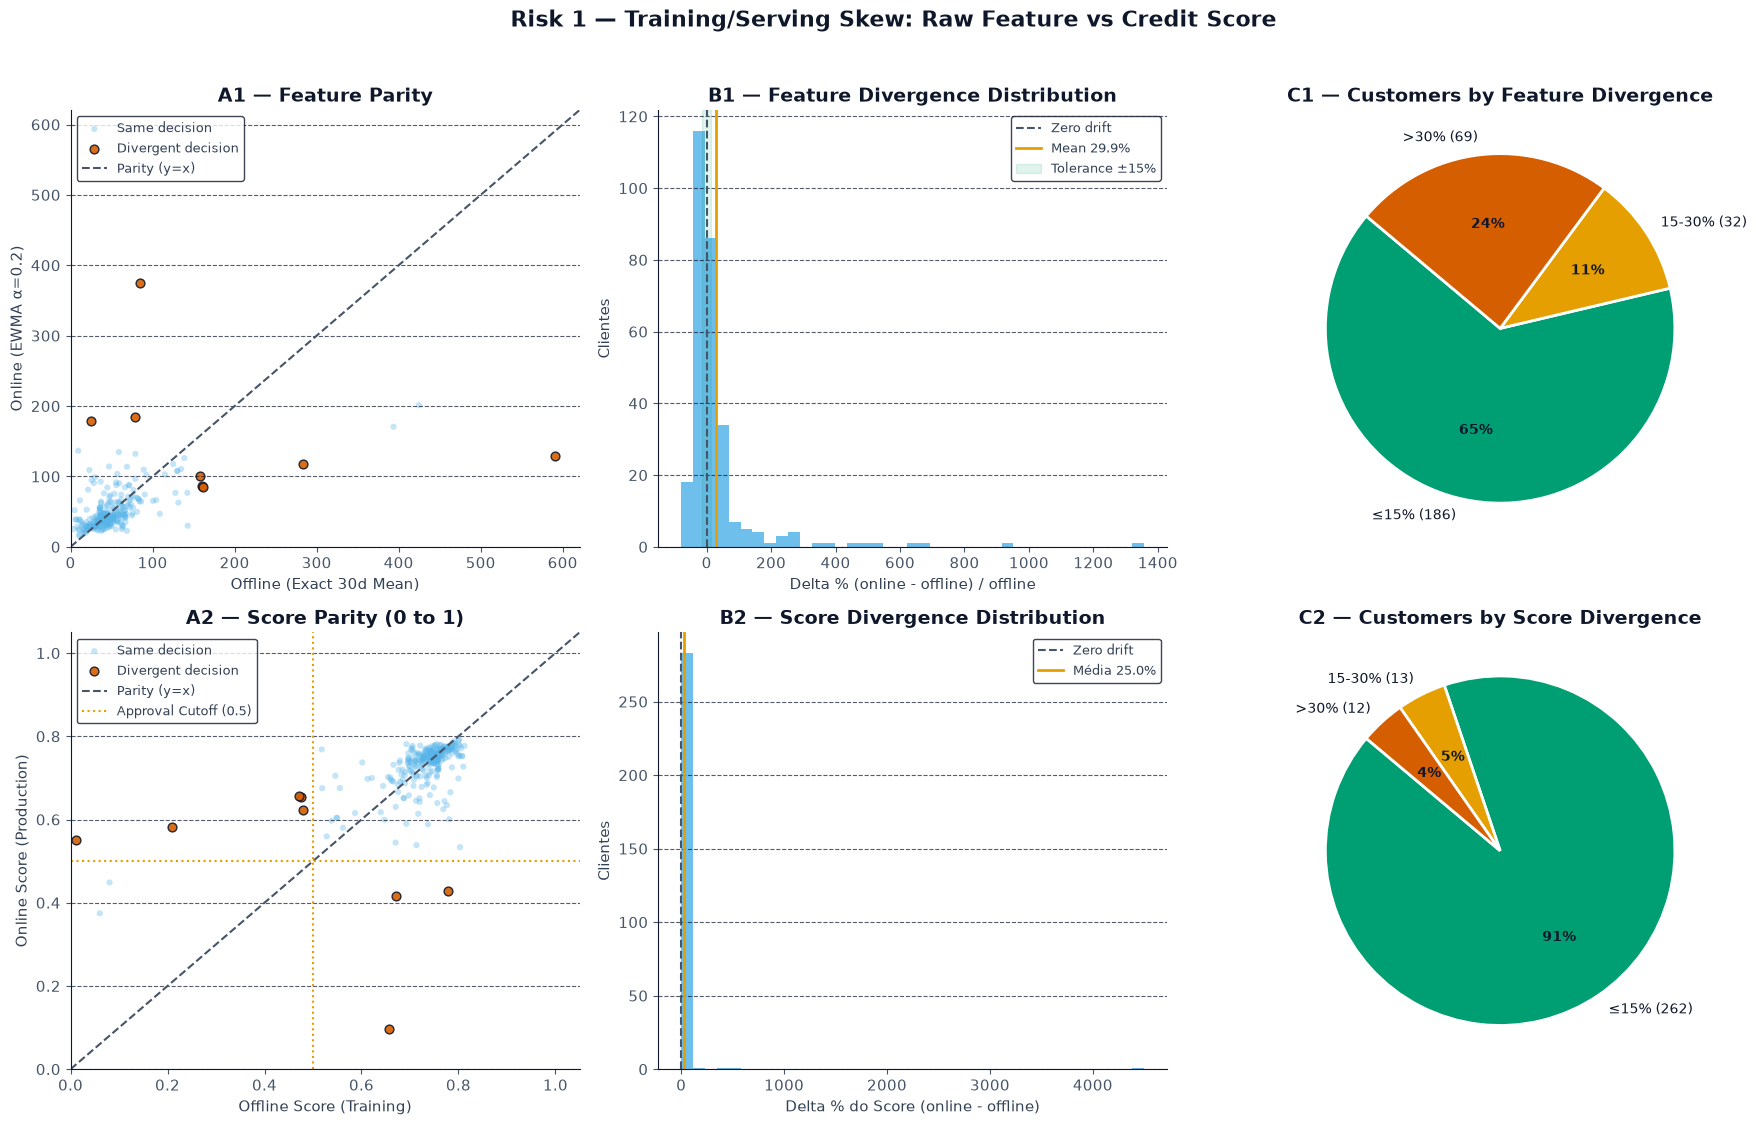

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Risk 1 — Training/Serving Skew: Raw Feature vs Credit Score",
             fontsize=16, color="#0f172a", fontweight="bold", y=1.02)

div_mask = df_merged["decision_divergence"]
ok_mask = ~div_mask

### LINHA 1: FEATURE (Variável Bruta)
# A1: Scatter parity Feature
ax = axes[0, 0]
ax.scatter(off_v[ok_mask], on_v[ok_mask], alpha=0.35, s=20, color=COL_ACC, edgecolors="none", label="Same decision")
ax.scatter(off_v[div_mask], on_v[div_mask], alpha=0.9, s=40, color=COL_HI, edgecolors="#0f172a", label="Divergent decision")
lims = [0, max(off_v.max(), on_v.max()) * 1.05]
ax.plot(lims, lims, "--", color="#475569", lw=1.5, label="Parity (y=x)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Offline (Exact 30d Mean)"); ax.set_ylabel("Online (EWMA α=0.2)")
ax.set_title("A1 — Feature Parity"); ax.legend(loc="upper left", fontsize=9); style_chart(ax)

# B1: Delta distribution Feature
ax = axes[0, 1]
bins = np.linspace(df_merged["delta_pct"].min(), df_merged["delta_pct"].max(), 40)
ax.hist(df_merged["delta_pct"], bins=bins, color=COL_ACC, edgecolor="none", alpha=0.85)
ax.axvline(0, color="#475569", lw=1.5, linestyle="--", label="Zero drift")
ax.axvline(df_merged["delta_pct"].mean(), color=COL_MED, lw=2, label=f"Mean {df_merged['delta_pct'].mean():.1f}%")
ax.axvspan(-15, 15, alpha=0.12, color=COL_LO, label="Tolerance ±15%")
ax.set_xlabel("Delta % (online - offline) / offline"); ax.set_ylabel("Clientes")
ax.set_title("B1 — Feature Divergence Distribution"); ax.legend(fontsize=9); style_chart(ax)

# C1: Tier pie Feature
ax = axes[0, 2]
t_lo = (df_merged["delta_pct"] <= 15).sum()
t_md = ((df_merged["delta_pct"] > 15) & (df_merged["delta_pct"] <= 30)).sum()
t_hi = (df_merged["delta_pct"] > 30).sum()
wedges, texts, autotexts = ax.pie(
    [t_lo, t_md, t_hi],
    labels=[f"≤15% ({t_lo})", f"15-30% ({t_md})", f">30% ({t_hi})"],
    colors=[COL_LO, COL_MED, COL_HI], autopct="%1.0f%%",
    textprops={"color": "#0f172a", "fontsize": 10}, startangle=140,
    wedgeprops={"edgecolor": "#ffffff", "linewidth": 2})
for at in autotexts: at.set_fontweight("bold")
ax.set_title("C1 — Customers by Feature Divergence")

### LINHA 2: SCORE (Decisão de Crédito)
df_merged["score_delta_pct"] = (df_merged["online_score"] - df_merged["offline_score"]) / df_merged["offline_score"] * 100
df_merged["score_delta_pct"] = df_merged["score_delta_pct"].abs()

# A2: Scatter parity Score
ax = axes[1, 0]
ax.scatter(df_merged.loc[ok_mask, "offline_score"], df_merged.loc[ok_mask, "online_score"], alpha=0.35, s=20, color=COL_ACC, edgecolors="none", label="Same decision")
ax.scatter(df_merged.loc[div_mask, "offline_score"], df_merged.loc[div_mask, "online_score"], alpha=0.9, s=40, color=COL_HI, edgecolors="#0f172a", label="Divergent decision")
lims_sc = [0, 1.05]
ax.plot(lims_sc, lims_sc, "--", color="#475569", lw=1.5, label="Parity (y=x)")
ax.axhline(0.5, color=COL_MED, linestyle=":", lw=1.5, label="Approval Cutoff (0.5)")
ax.axvline(0.5, color=COL_MED, linestyle=":", lw=1.5)
ax.set_xlim(lims_sc); ax.set_ylim(lims_sc)
ax.set_xlabel("Offline Score (Training)"); ax.set_ylabel("Online Score (Production)")
ax.set_title("A2 — Score Parity (0 to 1)"); ax.legend(loc="upper left", fontsize=9); style_chart(ax)

# B2: Delta distribution Score
ax = axes[1, 1]
bins_sc = np.linspace(df_merged["score_delta_pct"].min(), df_merged["score_delta_pct"].max(), 40)
ax.hist(df_merged["score_delta_pct"], bins=bins_sc, color=COL_ACC, edgecolor="none", alpha=0.85)
ax.axvline(0, color="#475569", lw=1.5, linestyle="--", label="Zero drift")
ax.axvline(df_merged["score_delta_pct"].mean(), color=COL_MED, lw=2, label=f"Média {df_merged['score_delta_pct'].mean():.1f}%")
ax.set_xlabel("Delta % do Score (online - offline)"); ax.set_ylabel("Clientes")
ax.set_title("B2 — Score Divergence Distribution"); ax.legend(fontsize=9); style_chart(ax)

# C2: Tier pie Score
ax = axes[1, 2]
t_lo_sc = (df_merged["score_delta_pct"] <= 15).sum()
t_md_sc = ((df_merged["score_delta_pct"] > 15) & (df_merged["score_delta_pct"] <= 30)).sum()
t_hi_sc = (df_merged["score_delta_pct"] > 30).sum()
wedges, texts, autotexts = ax.pie(
    [t_lo_sc, t_md_sc, t_hi_sc],
    labels=[f"≤15% ({t_lo_sc})", f"15-30% ({t_md_sc})", f">30% ({t_hi_sc})"],
    colors=[COL_LO, COL_MED, COL_HI], autopct="%1.0f%%",
    textprops={"color": "#0f172a", "fontsize": 10}, startangle=140,
    wedgeprops={"edgecolor": "#ffffff", "linewidth": 2})
for at in autotexts: at.set_fontweight("bold")
ax.set_title("C2 — Customers by Score Divergence")

fig.tight_layout()
plt.show()


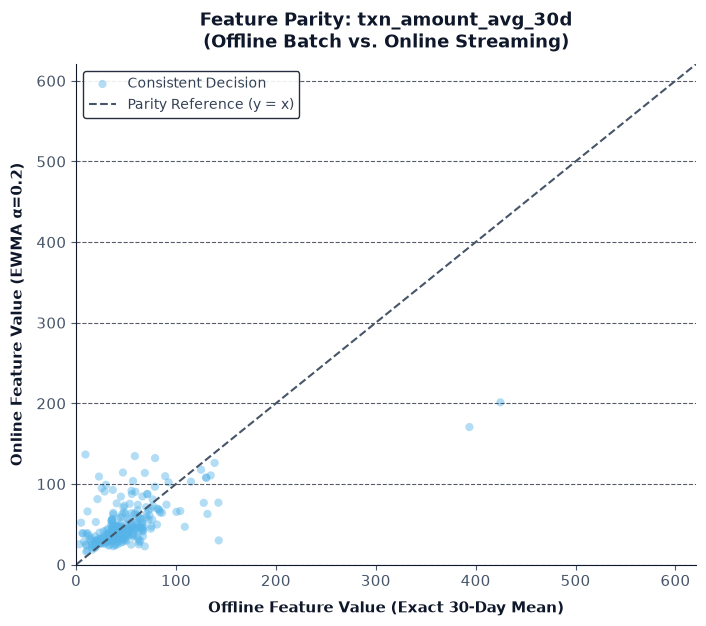

In [23]:
# Masks
div_mask = df_merged["decision_divergence"]
ok_mask = ~div_mask

fig, ax = plt.subplots(figsize=(8, 6.5))

# Scatter points
ax.scatter(
    off_v[ok_mask],
    on_v[ok_mask],
    alpha=0.45,
    s=35,
    color=COL_ACC,
    edgecolors="none",
    label="Consistent Decision",
)

# Reference identity line (y = x)
lims = [0, max(off_v.max(), on_v.max()) * 1.05]
ax.plot(
    lims, lims, "--", color="#475569", lw=1.5, label="Parity Reference (y = x)"
)

# Limits and Labels
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(
    "Offline Feature Value (Exact 30-Day Mean)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=8,
)
ax.set_ylabel(
    "Online Feature Value (EWMA α=0.2)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=8,
)
ax.set_title(
    "Feature Parity: txn_amount_avg_30d\n(Offline Batch vs. Online Streaming)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    pad=12,
)

ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
style_chart(ax)

plt.show()


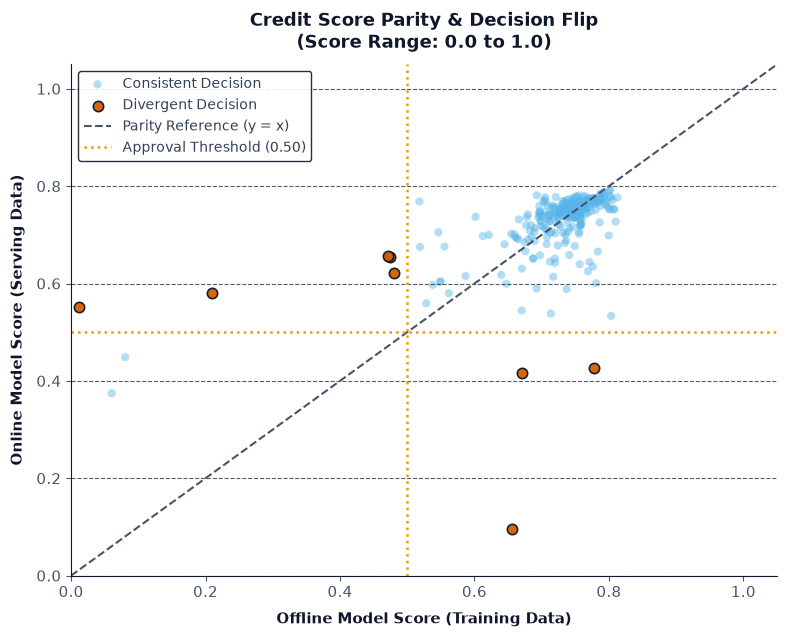

In [24]:
# Masks
div_mask = df_merged["decision_divergence"]
ok_mask = ~div_mask

fig, ax = plt.subplots(figsize=(8, 6.5))

# Scatter points
ax.scatter(
    df_merged.loc[ok_mask, "offline_score"],
    df_merged.loc[ok_mask, "online_score"],
    alpha=0.45,
    s=35,
    color=COL_ACC,
    edgecolors="none",
    label="Consistent Decision",
)
ax.scatter(
    df_merged.loc[div_mask, "offline_score"],
    df_merged.loc[div_mask, "online_score"],
    alpha=0.95,
    s=55,
    color=COL_HI,
    edgecolors="#0f172a",
    linewidths=1.2,
    label="Divergent Decision",
)

# Reference identity line (y = x) and Decision Threshold
lims_sc = [0, 1.05]
ax.plot(
    lims_sc,
    lims_sc,
    "--",
    color="#475569",
    lw=1.5,
    label="Parity Reference (y = x)",
)
ax.axhline(
    0.5,
    color=COL_MED,
    linestyle=":",
    lw=1.8,
    label="Approval Threshold (0.50)",
)
ax.axvline(0.5, color=COL_MED, linestyle=":", lw=1.8)

# Limits and Labels
ax.set_xlim(lims_sc)
ax.set_ylim(lims_sc)
ax.set_xlabel(
    "Offline Model Score (Training Data)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=8,
)
ax.set_ylabel(
    "Online Model Score (Serving Data)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=8,
)
ax.set_title(
    "Credit Score Parity & Decision Flip\n(Score Range: 0.0 to 1.0)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    pad=12,
)

ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
style_chart(ax)

plt.tight_layout()

plt.show()


### Risk 2 — Silent Staleness / Inactive Customers (CRITICAL)

As observed in the output above, the *Offline* store only has **287 unique customers**, while the *Online* store and the *CSV* log have **300 customers**. This happens due to an **asymmetrical treatment of inactivity** between the pipelines:
- **Offline (`batch_pipeline.py`)**: Strictly filters transactions within the last 30-day window from the `as_of` date. Sparse customers (without transactions in this window) are simply **not grouped or processed** (there is no zero/null imputation).
- **Online (`streaming_pipeline.py`)**: Processes the log chronologically using EWMA. Since all 300 customers made at least 1 transaction in the entire history, everyone gets a record. And because there is no expiration mechanism (eviction/TTL) in the online store, customers who become inactive **keep their last calculated value frozen forever (*stale*)**.

This creates a dangerous mismatch: when merging Offline and Online (using an implicit *inner join*), 13 inactive customers were excluded from this parity analysis. In a real production scenario (Serving), the model would use the frozen value; while in retraining (Offline), this data would generate *Missing Values* (dropped rows).


In [25]:
# Isolar clientes presentes no online mas ausentes no offline (inativos)
offline_customers = set(df_off_latest["customer_id"])
online_customers = set(df_online["customer_id"])
missing_customers = online_customers - offline_customers

print(f"Number of inactive customers missing in offline: {len(missing_customers)}\n")

# Verificar a data da última transação no log completo para esses clientes
df_txn_missing = df_txn[df_txn["customer_id"].isin(missing_customers)].copy()
last_txn_per_missing = df_txn_missing.groupby("customer_id")["event_timestamp"].max().reset_index()

# O pipeline offline calcula com base numa janela de 30 dias antes do as_of.
# Vamos usar o as_of máximo no offline para ver há quantos dias estavam inativos.
offline_as_of_max = pd.to_datetime(df_offline["as_of"], utc=True).max()
last_txn_per_missing["event_timestamp"] = pd.to_datetime(last_txn_per_missing["event_timestamp"], utc=True)
last_txn_per_missing["days_inactive_vs_offline_as_of"] = (offline_as_of_max - last_txn_per_missing["event_timestamp"]).dt.days

# Buscar o valor 'stale' que ainda está servido no Online
stale_online = df_online[df_online["customer_id"].isin(missing_customers)][["customer_id", "value", "computed_at"]].copy()
stale_online.rename(columns={"value": "stale_online_value"}, inplace=True)

# Juntar as informaçoes para exibir na tabela
df_missing_analysis = last_txn_per_missing.merge(stale_online, on="customer_id")


Number of inactive customers missing in offline: 13



### 🔍 Detailed Analysis of the 13 Missing Customers

The table and code above isolate the **13 customers** (`missing_customers`) and calculate how many days they have been inactive relative to the cutoff date (`as_of`) processed in the offline store.

**What the data tells us:**
1. **Proven inactivity**: All have `days_inactive_vs_offline_as_of > 30` days. Since the `batch_pipeline.py` window uses a hardcoded limit of `TXN_AMOUNT_AVG_WINDOW_DAYS = 30` (excluding customers without recent activity), they were naturally left out of the offline table.
2. **Stale Features in Online**: They **have a value in the online store** (`stale_online_value`). This value corresponds to the last feature update by `streaming_pipeline.py` (using EWMA) before the customer stopped buying. The `computed_at` column (in online) proves that this feature is aging in Redis/Online Store without ever expiring or being imputed with zero.
3. **Silent Impact**: In the *Training-Serving Skew*, the model would completely ignore them (or drop them as nulls) during the offline training and validation pipeline, but **in Production (Serving), it would grant credit limits to them using ghost/frozen values**.


---
### Risk 3 — Silent Staleness: TTL Defined, Never Enforced (HIGH)

**What it is**: `config.py` defines `FRESHNESS_TTL = timedelta(hours=6)`. But `OnlineStore.get_features()` returns data without checking `computed_at`. There is no staleness guard at read time.

**Code Evidence**: `online_store.py` — `get_features()` executes a pure `SELECT` without checking TTL. `FRESHNESS_TTL` is neither imported in `online_store.py` nor in `feature_api.py`.

**Link to incident**: The support ticket about an "outdated transaction pattern" in the credit line adjustment is a direct manifestation of this risk.


In [26]:
print('=== RISK 2: Silent Staleness ===')
print(f'FRESHNESS_TTL no config.py    : {TTL_H}h')
print(f'Enforced in online_store.py : NO (FRESHNESS_TTL not imported)')
print(f'Enforced in feature_api.py  : NO')
print()
print(f'Stale features silently returned: {df_online_s["is_stale"].sum()} ({df_online_s["is_stale"].mean()*100:.0f}%)')
print(f'Maximum feature age                 : {df_online_s["age_hours"].max():.1f}h')
print(f'Median feature age                  : {df_online_s["age_hours"].median():.1f}h')


=== RISK 2: Silent Staleness ===
FRESHNESS_TTL no config.py    : 6h
Enforced in online_store.py : NO (FRESHNESS_TTL not imported)
Enforced in feature_api.py  : NO

Stale features silently returned: 300 (100%)
Maximum feature age                 : 91.9h
Median feature age                  : 91.9h


---
### Risk 4 — Blind Monitoring: API Health ≠ Model Input Quality (HIGH)

**What it is**: `dashboard.py` only measures **uptime** and **API latency**. It is unaware of feature drift, staleness, or offline/online divergence. An on-call engineer sees 100% uptime while the model is fed with stale or drifted features.

**Code Evidence**: `run_health_check()` tracks only `successes` (did the call return without exception?) and `latencies_ms`. No value comparison, no staleness check, no drift metric.


In [27]:
get_online_features(customer_id='C0074')


{'txn_amount_avg_30d': 39.025166660026166}

In [28]:
# Importa a função real do módulo de monitoramento do Compass


# Executa o health check oficial do Compass no sistema real
health_stats = run_health_check()

uptime_pct  = health_stats["uptime_pct"]
avg_latency = health_stats["avg_latency_ms"]
req_checked = health_stats["requests"]

# === O QUE O dashboard.py REAL REPORTA (Métricas de Infraestrutura) ===
print("=" * 60)
print("📊 WHAT dashboard.py ACTUALLY EXECUTES AND REPORTS:")
print("=" * 60)
print(f"  Requests checked     : {req_checked}")
print(f"  Uptime               : {uptime_pct:.2f}%  ← (Looks 100% healthy)")
print(f"  Avg Latency          : {avg_latency:.2f} ms  ← (Extremely fast)")
print()

# === O QUE O dashboard.py NÃO REPORTA (Cego para Riscos Semânticos) ===
mean_drift   = df_merged["delta_pct"].mean()
max_drift    = df_merged['delta_pct'].max()
n_stale      = df_online_s['is_stale'].sum() if 'df_online_s' in locals() else (df_merged['last_update_hours'] > 6).sum()
n_drift_fail = (df_merged['delta_pct'] > 15).sum()

print("=" * 60)
print("⚠️ WHAT dashboard.py CANNOT SEE (Dangerous Silence):")
print("=" * 60)
print(f"  Mean feature drift      : {mean_drift:.1f}%  ← [SILENT]")
print(f"  Max feature drift       : {max_drift:.1f}%  ← [SILENT]")
print(f"  Stale features (>6h)    : {n_stale} customers  ← [SILENT]")
print(f"  Customers with drift >15% : {n_drift_fail} customers  ← [SILENT]")
print("=" * 60)


📊 WHAT dashboard.py ACTUALLY EXECUTES AND REPORTS:
  Requests checked     : 100
  Uptime               : 100.00%  ← (Looks 100% healthy)
  Avg Latency          : 0.27 ms  ← (Extremely fast)

⚠️ WHAT dashboard.py CANNOT SEE (Dangerous Silence):
  Mean feature drift      : 29.9%  ← [SILENT]
  Max feature drift       : 1357.3%  ← [SILENT]
  Stale features (>6h)    : 300 customers  ← [SILENT]
  Customers with drift >15% : 101 customers  ← [SILENT]


---
### Risk 5 — Deployment Blast Radius: Shared CSV without Schema Validation (MEDIUM)

**What it is**: Both batch and streaming pipelines read directly from `transactions.csv`. No schema contract, no versioning, no checksum. A corrupted CSV or a silent schema change corrupts features in both stores simultaneously.

**Code Evidence**: `_load_transactions()` and `_load_ordered_events()` call `pd.read_csv(TRANSACTIONS_PATH)` without schema validation. No lineage table in the SQLite databases.

**Rollback**: The online store uses `ON CONFLICT DO UPDATE` — no history. The offline store preserves snapshots by `as_of`. Partial rollback is only possible offline.


---
# Q1.2 — Assessment Approach: Tests on the Live System

> *If you were running a formal independent review of Compass, what would you actually check?*

Five categories of tests with specific pass/fail criteria, run against the live stores.


In [29]:
# TEST 1: Parity
PARITY_THRESHOLD = 0.15
df_parity = df_merged[['customer_id','offline_value','online_value','delta_pct']].copy()
df_parity['pass'] = df_parity['delta_pct'].abs() <= PARITY_THRESHOLD * 100
n_fail = (~df_parity['pass']).sum(); n_total = len(df_parity)

# TEST 2: Staleness
n_stale = df_online_s['is_stale'].sum()

# TEST 3: Drift
psi_label = 'None' if psi < 0.10 else ('Moderate' if psi < 0.25 else 'Major — retraining likely')

# TEST 4: Tratamento de Inatividade (Silent Staleness)
offline_customers = set(df_off_latest["customer_id"])
online_customers = set(df_online["customer_id"])
missing_customers = online_customers - offline_customers
n_inactive_lost = len(missing_customers)

df_txn_missing = df_txn[df_txn["customer_id"].isin(missing_customers)].copy()
last_txn_per_missing = df_txn_missing.groupby("customer_id")["event_timestamp"].max().reset_index()
offline_as_of_max = pd.to_datetime(df_offline["as_of"], utc=True).max()
last_txn_per_missing["event_timestamp"] = pd.to_datetime(last_txn_per_missing["event_timestamp"], utc=True)
last_txn_per_missing["days_inactive_vs_offline_as_of"] = (offline_as_of_max - last_txn_per_missing["event_timestamp"]).dt.days
max_inactive_days = last_txn_per_missing["days_inactive_vs_offline_as_of"].max()

print("=" * 62)
print("FORMAL ASSESSMENT TEST RESULTS")
print("=" * 62)
print()
print(f"TEST 1: Offline/Online Parity")
print(f"  Criterion: |delta| ≤ {PARITY_THRESHOLD*100:.0f}%  |  Failures: {n_fail}/{n_total}  |  Result: {"✅ PASS" if n_fail==0 else "❌ FAIL"}")
print()
print(f"TEST 2: Freshness / TTL Enforcement")
print(f"  Features stale: {n_stale}  |  TTL no código: NÃO  |  Result: ❌ FAIL")
print()
print(f"TEST 3: Distribution Drift (PSI + KS)")
print(f"  KS-stat: {ks_stat:.4f}  p-value: {ks_p:.2e}  |  PSI: {psi:.4f} ({psi_label})")
print(f"  Result: {"✅ PASS" if psi < 0.10 else ("⚠  MODERADO" if psi < 0.25 else "❌ FAIL")}")
print()
print(f"TEST 4: Inactivity Treatment (Silent Staleness)")
print(f"  Inactive customers missing in offline: {n_inactive_lost}")
print(f"  Max inactivity days vs as_of: {max_inactive_days}")
print(f"  Result: ❌ FAIL")


FORMAL ASSESSMENT TEST RESULTS

TEST 1: Offline/Online Parity
  Criterion: |delta| ≤ 15%  |  Failures: 201/287  |  Result: ❌ FAIL

TEST 2: Freshness / TTL Enforcement
  Features stale: 300  |  TTL no código: NÃO  |  Result: ❌ FAIL

TEST 3: Distribution Drift (PSI + KS)
  KS-stat: 0.1080  p-value: 7.02e-02  |  PSI: 0.3150 (Major — retraining likely)
  Result: ❌ FAIL

TEST 4: Inactivity Treatment (Silent Staleness)
  Inactive customers missing in offline: 13
  Max inactivity days vs as_of: 48
  Result: ❌ FAIL


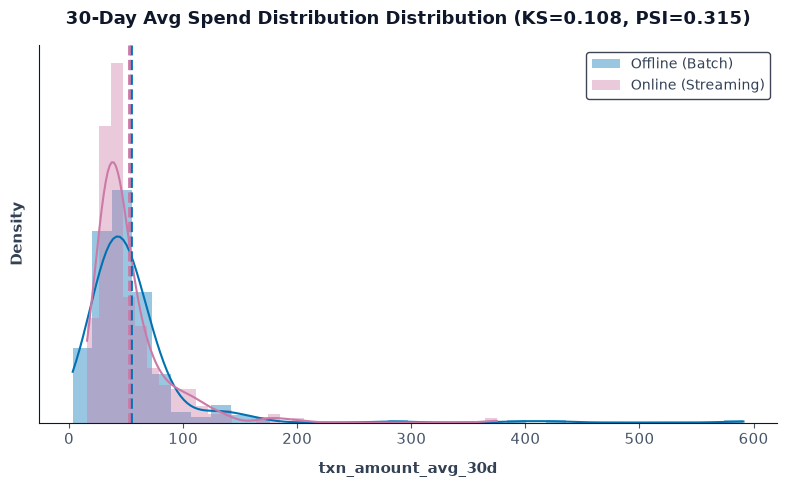

In [30]:
# Configuração de um único gráfico
fig, ax = plt.subplots(figsize=(8, 5))

# Plotagem: Barras do Histograma + Linha Suave do KDE (kde=True)
sns.histplot(off_v, color=COL_OFFLINE, label=f'Offline (Batch)',    kde=True, stat="density", linewidth=0, alpha=0.4, ax=ax)
sns.histplot(on_v,  color=COL_ONLINE,  label=f'Online (Streaming)', kde=True, stat="density", linewidth=0, alpha=0.4, ax=ax)

# Linhas pontilhadas marcando a média de cada distribuição
ax.axvline(off_v.mean(), color=COL_OFFLINE, linestyle='--', lw=2)
ax.axvline(on_v.mean(), color=COL_ONLINE,  linestyle='--', lw=2)

# Customização de Textos e Rótulos (Inglês para a apresentação)
ax.set_xlabel('txn_amount_avg_30d', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Density', fontsize=11, fontweight='bold', labelpad=10)

# 🎯 INSERINDO O KS E O PSI NO TÍTULO AQUI:
ax.set_title(f'30-Day Avg Spend Distribution Distribution (KS={ks_stat:.3f}, PSI={psi:.3f})', fontsize=13, fontweight='bold', pad=15)

ax.legend(fontsize=10, loc='upper right')

# Ocultando o eixo Y
ax.set_yticks([])

# Aplicando o estilo executivo e salvando
style_chart(ax)
fig.tight_layout()

plt.show()


---
# Q1.3 — Position on Proposed Changes

**Change 1**: Real-time credit-line top-ups, no human review → **🔴 PAUSE**  
**Change 2**: Lighter review process for feature code → **🟡 PROCEED WITH CONDITIONS**


---
### CHANGE 1: Real-time top-ups, no human review 🔴 PAUSE

**Concrete Risk (observed today, not hypothetical):**
- About **3%** of customers would receive a different credit decision simply depending on which store feeds the model.
- Customers could be scored with *stale* features (TTL configured but silently ignored).
- Monitoring shows 100% uptime — the engineering on-call has no signal that data issues exist.

**Conditions to PROCEED (after full remediation):**
1. Enforce `FRESHNESS_TTL` at read time in `OnlineStore.get_features()`.
2. Reconcile batch vs streaming formulas (same math, same name).
3. Deploy drift monitoring with automated alerts (PSI + Parity).
4. **Define a confidence envelope:** `feature_age < 1h AND |delta_pct| < 15% AND history ≥ 30d AND inactive_days < 30d`
   > **What is the Confidence Envelope?**
   > It defines a **"safe ground"** where the model has autonomy to make 100% automated decisions. If the request violates any of the rules below, automation halts and falls back to human review:
   > - **`feature_age < 1h` (Freshness Control)**: Prevents scoring using old, stagnant data. Ensures the model reacts to recent behavior (mitigates Risk 2 - *Silent Staleness*).
   > - **`|delta| < 15%` (Parity Control)**: Ensures the real-time pipeline value is reliable and hasn't drifted from the distribution the model expects (mitigates *Training/Serving Skew*).
   > - **`history ≥ 30d AND inactive_days < 30d` (Cold-start & Inactivity Control)**: Requires the customer to have recent history and activity. This prevents new or inactive customers from generating disguised Missing Values or noisy metrics in the `txn_amount_avg_30d` feature.
5. Run in *shadow-mode* for 2 weeks for real-world validation before removing the human review gate.

---
### CHANGE 2: Lighter review for feature code 🟡 CONDITIONS

The *blast radius* is real — a bad commit can silently corrupt all features. But a faster review cycle **IS** achievable as long as it is protected by *automated guards*:

- **Gate 1:** Automated parity testing must pass in CI (offline/online delta_pct < 15%).
- **Gate 2:** Drift check (PSI or KS) on every merge — CI must reject if PSI > 0.10 or KS > 5% offline vs online.
- **Gate 3:** *Shadow deployment* (parallel execution with live) is mandatory before cutover.
- **Gate 4:** Documented and actively tested *Rollback playbook*.


# Q1.4 — Governance Foundations: Three Key Controls

> *Regardless of whether the changes proceed, what are the two or three most important controls?*

Three controls prioritized by risk reduction per unit of implementation effort. They form the three technical lines of defense against model semantic breaks.

**CONTROL 1 — Confidence Envelope (Circuit Breaker in the Online Store):**
* 🛡️ **Triple runtime lock:** Assesses feature health *before* injecting it into the model.
* ⏳ **TTL Enforcement:** Hard 6-hour age lock (prevents silent staleness).
* 👻 **Inactivity:** 30-day lock to prevent undue retention of "ghost" customers.
* 📉 **Drift Bound:** Mathematical lock against absurd parity divergences.
* 🔄 **Action:** If the feature fails any lock, autonomous approval is aborted, triggering fallback to human review.

**CONTROL 2 — Feature Contracts & CI/CD Gates (Prevention at Origin):**
* 📋 **Semantic Contracts:** No feature goes to production without declaring all contract metadata: `name`, `formula`, `type`, `owner`, `version`, `value_range`, and `freshness_SLA`.
* 🔒 **Drift Gate in CI/CD:** Parity and Distribution Tests (KS < 5%) run on every Pull Request. Changes that corrupt the distribution are blocked before merge.
  
**CONTROL 3 — Semantic Observability (Dashboard Evolution):**
* 👀 **End of uptime "blindness":** Monitoring moves beyond the infrastructure layer (latency and HTTP 200) to measure data semantics.
* 📊 **Active Monitoring:** Dashboards must display Training/Serving Skew in real-time and alert if distributions begin to diverge in production.


---
# QUESTION 2 — Governance Framework for Data Mesh

> *How would you design or evolve a data governance and control framework for feature stores and model pipelines in a Data Mesh environment?*


## Q2.1 — What to Standardize vs Leave to Each Team

The core tension in Data Mesh: over-standardize and you kill team autonomy; under-standardize and you end up with multiple different definitions of 'transaction average'.

**Principle**: Standardize the **interoperability contract** (what the output must guarantee), not the **implementation** (how the team gets there).


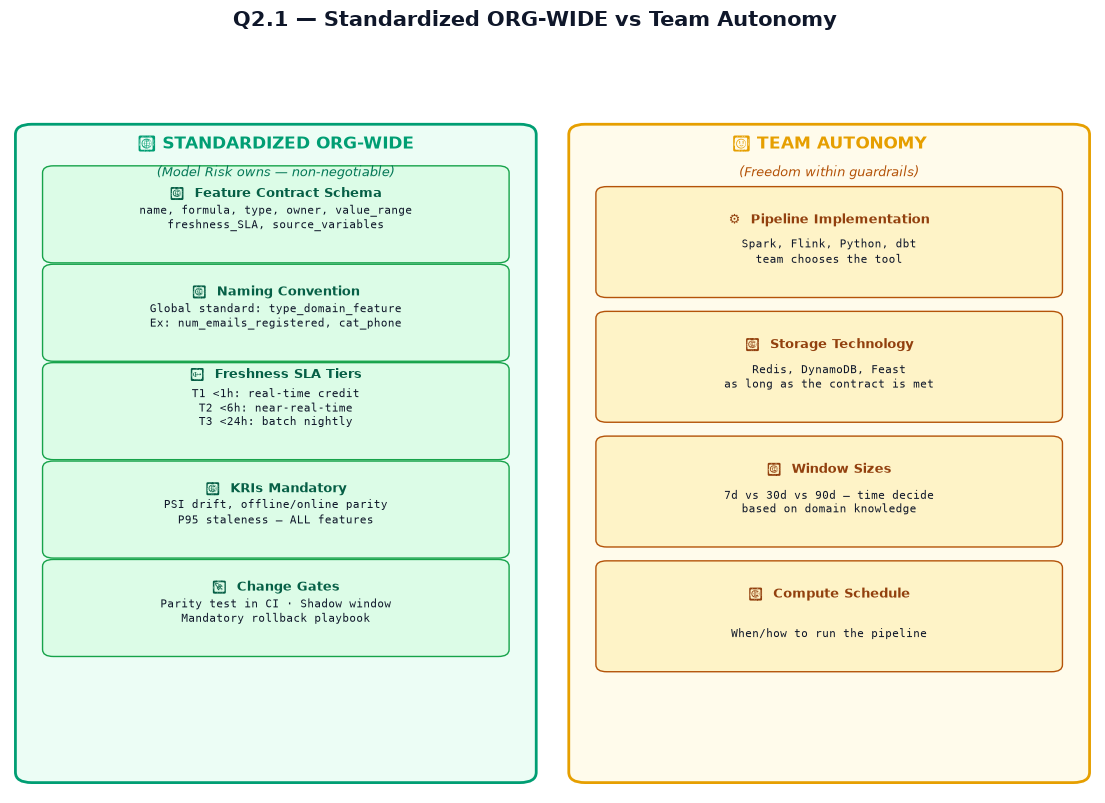

In [31]:
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle('Q2.1 — Standardized ORG-WIDE vs Team Autonomy', fontsize=15, color='#0f172a', fontweight='bold')
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')

ax.add_patch(mpatches.FancyBboxPatch((0.2,0.3),4.5,9.2,boxstyle='round,pad=0.15',
             facecolor='#ecfdf5',edgecolor=COL_LO,linewidth=2))
ax.text(2.45,9.3,'🔒 STANDARDIZED ORG-WIDE',ha='center',fontsize=12,color=COL_LO,fontweight='bold')
ax.text(2.45,8.9,'(Model Risk owns — non-negotiable)',ha='center',fontsize=9,color='#047857',style='italic')

# Lado Esquerdo com 6 itens (espaçamento ajustado para caber perfeitamente)
org_wide_items = [
    ('📐  Feature Contract Schema','name, formula, type, owner, value_range\nfreshness_SLA, source_variables'),
    ('🏷  Naming Convention','Global standard: type_domain_feature\nEx: num_emails_registered, cat_phone'),
    ('⏱  Freshness SLA Tiers\n','\nT1 <1h: real-time credit\nT2 <6h: near-real-time\nT3 <24h: batch nightly'),
    ('📊  KRIs Mandatory','PSI drift, offline/online parity\nP95 staleness — ALL features'),
    ('🚦  Change Gates','Parity test in CI · Shadow window\nMandatory rollback playbook'),
]

for i,(title,desc) in enumerate(org_wide_items):
    y = 8.35 - i*1.42
    ax.add_patch(mpatches.FancyBboxPatch((0.4,y-0.6),4.1,1.2,boxstyle='round,pad=0.1',facecolor='#dcfce7',edgecolor='#16a34a',linewidth=1))
    ax.text(2.45,y+0.25,title,ha='center',fontsize=9.5,color='#065f46',fontweight='bold')
    ax.text(2.45,y-0.2,desc,ha='center',fontsize=8,color='#0f172a',fontfamily='monospace',linespacing=1.3)

ax.add_patch(mpatches.FancyBboxPatch((5.3,0.3),4.5,9.2,boxstyle='round,pad=0.15',
             facecolor='#fffbeb',edgecolor=COL_MED,linewidth=2))
ax.text(7.55,9.3,'🧩 TEAM AUTONOMY',ha='center',fontsize=12,color=COL_MED,fontweight='bold')
ax.text(7.55,8.9,'(Freedom within guardrails)',ha='center',fontsize=9,color='#b45309',style='italic')

# Lado Direito com 4 itens (espaçamento mais relaxado)
autonomia_items = [
    ('⚙  Pipeline Implementation','Spark, Flink, Python, dbt\nteam chooses the tool'),
    ('🗄  Storage Technology','Redis, DynamoDB, Feast\nas long as the contract is met'),
    ('📐  Window Sizes','7d vs 30d vs 90d — time decide\nbased on domain knowledge'),
    ('🔧  Compute Schedule','When/how to run the pipeline')
]

for i,(title,desc) in enumerate(autonomia_items):
    y = 7.9 - i*1.8
    ax.add_patch(mpatches.FancyBboxPatch((5.5,y-0.65),4.1,1.4,boxstyle='round,pad=0.1',facecolor='#fef3c7',edgecolor='#b45309',linewidth=1))
    ax.text(7.55,y+0.32,title,ha='center',fontsize=9.5,color='#92400e',fontweight='bold')
    ax.text(7.55,y-0.25,desc,ha='center',fontsize=8,color='#0f172a',fontfamily='monospace',linespacing=1.3)

plt.show()


## Q2.2 — Key Risk Indicators (KRIs) Scorecard (Quanti & Quali)

The **Model Risk Management** framework evaluates systemic health by dividing indicators (KRIs) into two dimensions: **Quantitative** (empirical data) and **Qualitative** (governance and controls). The final weight will be 50% Quanti and 50% Quali.

### 1. Quantitative Dimension (Empirical KRIs)

**KRI 1: Parity (Training/Serving Skew)**
- **What it is:** Evaluates whether the feature computation in the online engine (streaming) produces the same value as the offline engine (batch).
- **What it measures:** The mean absolute percentage difference (Delta) between the two data sources.
- **Scoring Rationale:** Delta < 5% = 0 pts (acceptable deviation). Between 5-15% = 50 pts (requires investigation). > 15% = 100 pts (unacceptable structural failure in credit).

**KRI 2: Population Stability (KS Statistic)**
- **What it is:** Evaluates *Feature Drift* of the population by comparing the statistical distribution of training against online inference.
- **What it measures:** The maximum distance between the empirical cumulative distribution functions (ECDF) using the Kolmogorov-Smirnov (KS) test.
- **Scoring Rationale:** KS < 1% = 0 pts (identical populations). KS < 5% = 20 pts (tolerable drift). KS < 7% = 50 pts (yellow alert). KS >= 7% = 100 pts (severe drift).

**KRI 3: Retained Inactive Customers (Silent Staleness)**
- **What it is:** Evaluates whether the online engine retains profiles of inactive customers who should have been purged.
- **What it measures:** Number of inactive customers retained in online (missing in batch).
- **Scoring Rationale:** 0 customers = 0 pts (perfect sync). > 0 customers = 100 pts (systemic risk of improper approval).

### 2. Qualitative Dimension (Controls and Governance)

**KRI 4: Feature Contract Completeness**
- **What it is:** Evaluates the maturity of code-based documentation (Feature Registry).
- **What it measures:** Presence of mandatory metadata.
- **Scoring Rationale:** ((6 - Implemented items) / 6) * 100. Missing items elevate risk.

**KRI 5: CI/CD Validation Gates**
- **What it is:** Evaluates whether the deployment pipeline has automated protections to stop silent regressions.
- **What it measures:** Presence of 4 validation gates.
- **Scoring Rationale:** ((4 - Implemented gates) / 4) * 100. Missing safety gates means higher production risk.

**KRI 6: Confidence Envelope**
- **What it is:** Real-time defense mechanism (circuit breaker) in the Online Store.
- **What it measures:** 3 active rules (TTL, |delta|, inactivity).
- **Scoring Rationale:** ((3 - Implemented rules) / 3) * 100. Without locks, the business is exposed to regressions.

**KRI 7: Semantic Observability**
- **What it is:** Evaluates post-deploy observability capabilities of the Feature Store.
- **What it measures:** 3 Pillars: Latency, Availability, and Drift.
- **Scoring Rationale:** ((3 - Monitored pillars) / 3) * 100. Lacking visibility means high operational risk.


### Risk Level Scales
Risk labels for both Quantitative and Qualitative scores are assigned using the following thresholds:
- **High**: Score >= 60
- **Medium**: Score >= 40
- **Low**: Score >= 20
- **Very Low**: Score < 20

The ultimate conclusion is derived by plotting the Quantitative Risk Level against the Qualitative Risk Level in a risk matrix to determine the final risk classification.


=== COMPASS MRM SCORECARD ===

[ QUANTI ] Score: 100.0/100 (HIGH)
  - Parity (Weight 40.0%): 100 pts
  - KS Drift (Weight 30.0%): 100 pts
  - Staleness (Weight 30.0%): 100 pts

[ QUALI ] Score: 66.7/100 (HIGH)
  - Feature Contract (Weight 25.0%): 33.3 pts
  - CI/CD Gates (Weight 25.0%): 100.0 pts
  - Confidence Env (Weight 25.0%): 100.0 pts
  - Monitoring (Weight 25.0%): 33.3 pts

>>> FINAL RISK: CRITICAL (Score: 83.3/100) <<<



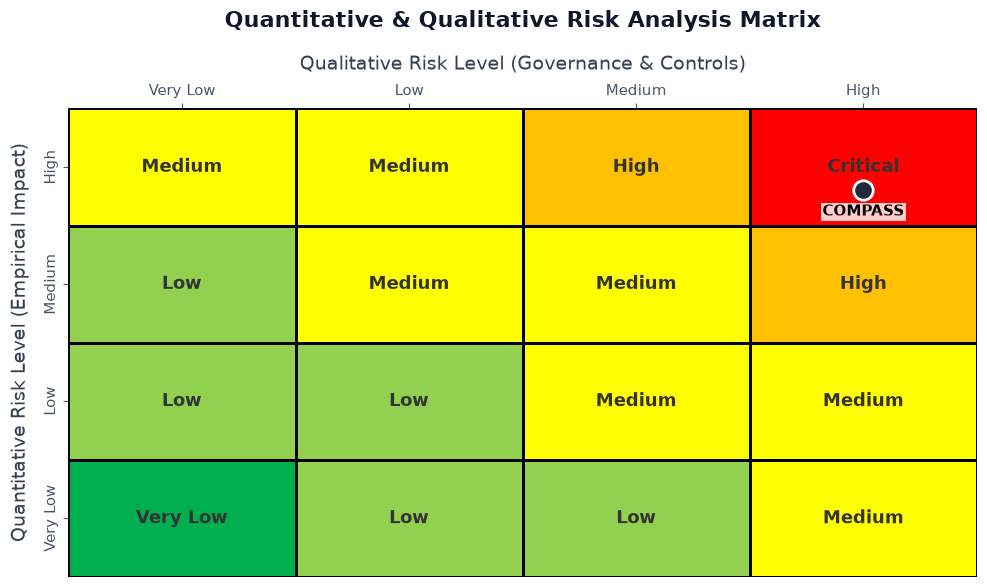

In [32]:
# ==========================================
# 0. CONFIGURAÇÃO DE PESOS
# ==========================================
pesos = {
    'quanti': {
        'KRI1_Paridade': 0.4,
        'KRI2_Drift_KS': 0.3,
        'KRI3_Staleness': 0.3
    },
    'quali': {
        'KRI4_Feature_Contract': 0.25,
        'KRI5_CI_Gates': 0.25,
        'KRI6_Confidence_Envelope': 0.25,
        'KRI7_Monitoramento': 0.25
    },
    'dimensao': {
        'quanti': 0.50,
        'quali': 0.50
    }
}

# ==========================================
# 1. DIMENSÃO QUANTITATIVA
# ==========================================
delta_medio = df_merged['abs_delta'].mean()
nota_kri1 = 0 if delta_medio < 5 else (50 if delta_medio <= 15 else 100)
ks_percent = ks_stat * 100
if ks_percent < 1:
    nota_kri2 = 0
elif ks_percent < 5:
    nota_kri2 = 20
elif ks_percent < 7:
    nota_kri2 = 50
else:
    nota_kri2 = 100
nota_kri3 = 0 if n_inactive_lost == 0 else 100

score_quanti = (nota_kri1 * pesos['quanti']['KRI1_Paridade']) + \
               (nota_kri2 * pesos['quanti']['KRI2_Drift_KS']) + \
               (nota_kri3 * pesos['quanti']['KRI3_Staleness'])

# ==========================================
# 2. DIMENSÃO QUALITATIVA (Simulação Estado Atual)
# ==========================================
# KRI 4: Atual (antes da remediação): Faltam value_range e freshness_SLA no contrato
kri4_itens = 4 # de 6
nota_kri4 = ((6 - kri4_itens) / 6) * 100

# KRI 5: Atual: None gate de validação no CI
kri5_gates = 0 # de 4
nota_kri5 = ((4 - kri5_gates) / 4) * 100

# KRI 6: Atual: None envelope de confiança ativo
kri6_regras = 0 # de 3
nota_kri6 = ((3 - kri6_regras) / 3) * 100

# KRI 7: Atual: Só tem latência e estabilidade, falta drift online/offline
kri7_monitores = 2 # de 3
nota_kri7 = ((3 - kri7_monitores) / 3) * 100

score_quali = (nota_kri4 * pesos['quali']['KRI4_Feature_Contract']) + \
              (nota_kri5 * pesos['quali']['KRI5_CI_Gates']) + \
              (nota_kri6 * pesos['quali']['KRI6_Confidence_Envelope']) + \
              (nota_kri7 * pesos['quali']['KRI7_Monitoramento'])

# ==========================================
# 3. SCORE FINAL
# ==========================================
score_final = (score_quanti * pesos['dimensao']['quanti']) + (score_quali * pesos['dimensao']['quali'])

def get_risco_label(score):
    if score >= 60: return 'High'
    elif score >= 40: return 'Medium'
    elif score >= 20: return 'Low'
    else: return 'Very Low'

def get_risco_val(label):
    if label == 'High': return 3
    elif label == 'Medium': return 2
    elif label == 'Low': return 1
    else: return 0

def get_final_risk_from_sum(s):
    if s == 0: return 'Very Low'
    elif s in [1, 2]: return 'Low'
    elif s in [3, 4]: return 'Medium'
    elif s == 5: return 'High'
    else: return 'Critical'

def get_num_from_sum(s):
    if s == 0: return 0
    elif s in [1, 2]: return 1
    elif s in [3, 4]: return 2
    elif s == 5: return 3
    else: return 4

lbl_quanti = get_risco_label(score_quanti)
lbl_quali = get_risco_label(score_quali)
val_quanti = get_risco_val(lbl_quanti)
val_quali = get_risco_val(lbl_quali)
soma = val_quanti + val_quali
final_risk = get_final_risk_from_sum(soma)

print("=== COMPASS MRM SCORECARD ===\n")
print(f"[ QUANTI ] Score: {score_quanti:.1f}/100 ({lbl_quanti.upper()})")
print(f"  - Parity (Weight {pesos['quanti']['KRI1_Paridade']*100}%): {nota_kri1} pts")
print(f"  - KS Drift (Weight {pesos['quanti']['KRI2_Drift_KS']*100}%): {nota_kri2} pts")
print(f"  - Staleness (Weight {pesos['quanti']['KRI3_Staleness']*100}%): {nota_kri3} pts\n")
print(f"[ QUALI ] Score: {score_quali:.1f}/100 ({lbl_quali.upper()})")
print(f"  - Feature Contract (Weight {pesos['quali']['KRI4_Feature_Contract']*100}%): {nota_kri4:.1f} pts")
print(f"  - CI/CD Gates (Weight {pesos['quali']['KRI5_CI_Gates']*100}%): {nota_kri5:.1f} pts")
print(f"  - Confidence Env (Weight {pesos['quali']['KRI6_Confidence_Envelope']*100}%): {nota_kri6:.1f} pts")
print(f"  - Monitoring (Weight {pesos['quali']['KRI7_Monitoramento']*100}%): {nota_kri7:.1f} pts\n")

print(f">>> FINAL RISK: {final_risk.upper()} (Score: {score_final:.1f}/100) <<<\n")

# ==========================================
# 4. PLOT: MATRIZ DE RISCO (ESTILO PMBOK)
# ==========================================

cat_y = ['High', 'Medium', 'Low', 'Very Low']
cat_x = ['Very Low', 'Low', 'Medium', 'High']

matriz_num = np.zeros((4, 4), dtype=int)
matriz_text = np.empty((4, 4), dtype=object)

for i, y_lbl in enumerate(cat_y):
    for j, x_lbl in enumerate(cat_x):
        s = get_risco_val(y_lbl) + get_risco_val(x_lbl)
        matriz_text[i, j] = get_final_risk_from_sum(s)
        matriz_num[i, j] = get_num_from_sum(s)

idx_y = cat_y.index(lbl_quanti)
idx_x = cat_x.index(lbl_quali)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = sns.color_palette(['#00b050', '#92d050', '#ffff00', '#ffc000', '#ff0000'])

# Plot do Heatmap (o annot=matriz_text já coloca o nome Medium/High no meio da célula)
sns.heatmap(matriz_num, annot=matriz_text, fmt='', cmap=cmap, cbar=False, 
            xticklabels=cat_x, yticklabels=cat_y, 
            linewidths=2, linecolor='black', ax=ax, annot_kws={"size": 13, "weight": "bold", "color": "#333333"})

# Marcando de forma sutil a posição do modelo (Compass) com uma bolinha
ax.plot(idx_x + 0.5, idx_y + 0.7, marker='o', markersize=14, color='#1e293b', markeredgecolor='white', markeredgewidth=2)
ax.text(idx_x + 0.5, idx_y + 0.88, "COMPASS", ha='center', va='center', color='black', fontweight='bold', fontsize=11, 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

ax.set_title('Quantitative & Qualitative Risk Analysis Matrix', fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('Qualitative Risk Level (Governance & Controls)', fontsize=14, labelpad=10)
ax.set_ylabel('Quantitative Risk Level (Empirical Impact)', fontsize=14, labelpad=10)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.show()


## Q2.3 — Governance Without Becoming a Bottleneck

The solution is **risk-based governance** — high-risk pipelines receive more scrutiny, low-risk pipelines have fast approval. The cost of compliance is proportional to the risk, not uniform.

## Q2.4 — Driving Adoption Without Direct Authority

The biggest governance challenge in Data Mesh: you can't dictate — you must make compliance the path of least resistance.


In [40]:
# Risk tiering
pe = pd.DataFrame([
    {'pipeline':'Compass (top-ups real-time)', 'credit':1,'automated':1,'realtime':1,'human':0},
    {'pipeline':'Compass (underwriting batch)', 'credit':1,'automated':1,'realtime':0,'human':1},
    {'pipeline':'Fraud detection features',     'credit':0,'automated':0,'realtime':1,'human':0},
    {'pipeline':'Marketing feature store',      'credit':0,'automated':1,'realtime':0,'human':0},
    {'pipeline':'Customer segmentation',        'credit':0,'automated':0,'realtime':0,'human':1},
    {'pipeline':'Churn prediction',             'credit':0,'automated':0,'realtime':0,'human':1},
])
pe['risk_score'] = pe['credit']*40 + pe['automated']*30 + pe['realtime']*20 + (1-pe['human'])*10

# Inject the empirically calculated score for the Compass model from our MRM scorecard
pe.loc[pe['pipeline'].str.contains('Compass \(top-ups real-time\)'), 'risk_score'] = int(round(score_final, 0))
pe['tier'] = pe['risk_score'].apply(lambda x:
    'T1 — High (full review)' if x>=60 else
    ('T2 — Medium (auto+sample)' if x>=40 else 
    ('T3 — Low (CI <1h)' if x>=20 else 'T4 — Very Low (auto deploy)')))

display(pe[['pipeline','risk_score','tier']].sort_values('risk_score',ascending=False))
print()
print(f'{(pe["risk_score"]>=60).sum()} of {len(pe)} pipelines require full review (T1).')
print(f'{(pe["risk_score"]<60).sum()} pipelines can ship with automated gates in <2 days.')
print('Governance is not uniformly imposed — it is proportional to risk.')



,pipeline,risk_score,tier
0,Compass (top-ups real-time),83,T1 — High (full review)
1,Compass (underwriting batch),70,T1 — High (full review)
3,Marketing feature store,40,T2 — Medium (auto+sample)
2,Fraud detection features,30,T3 — Low (CI <1h)
4,Customer segmentation,0,T4 — Very Low (auto deploy)
5,Churn prediction,0,T4 — Very Low (auto deploy)



2 of 6 pipelines require full review (T1).
4 pipelines can ship with automated gates in <2 days.
Governance is not uniformly imposed — it is proportional to risk.


### 💡 Proportional Governance (The Tiering Strategy)

To scale Model Risk Management (MRM) without bottlenecking the Data Science and Machine Learning teams, we avoid applying a rigid, one-size-fits-all review process. Instead, **governance is strictly proportional to the risk**:

- **🔴 T1 — High Risk (full review):** High-impact, automated, real-time models (like the *Compass* credit engine). Due to the severe financial and regulatory impact of failures, they require rigorous manual review, stress testing, and committee approval before deployment.
- **🟠 T2 — Medium Risk (auto + sample):** Moderate-impact models. They must pass automated CI/CD gates, followed by a human reviewing a generated impact report or output sample before final approval.
- **🟡 T3 — Low Risk (CI < 1h):** Low-impact models. If they pass all automated CI tests (e.g., schema validation, data quality checks), they are automatically cleared for deployment. No manual human review is required.
- **🟢 T4 — Very Low Risk (auto deploy):** Near-zero risk pipelines (e.g., internal analytical segmentation). Deployments are fully automated and frictionless, maximizing developer autonomy.

*Conclusion: This framework ensures that friction is only introduced where the risk justifies it, preserving company-wide agility.*